# All you need to know about Taylor Swift lyrics

In this notebook, I will analyse all Taylor Swift lyrics from 12 albums, movie soundtracks and some musics from the vault. This analysis was conducted in mid June 2026, yes, "I knew it, I knew you" is also included.

## Table of Contents
I. [Analysing Lyrics by Album](#i-analysing-lyrics-by-album)  
II. [Analysing Words by Song](#ii-analysing-words-by-song)  
III. [Analysing All Words over 251 Songs](#iii-analysing-all-words-over-251-songs)  
IV. [Conclusion and Discussion](#iv-conclusion-and-discussion)

## Getting start

In [199]:
from bs4 import BeautifulSoup
import re
import lyricsgenius
import requests
from pathlib import Path
import pandas as pd
import numpy as np

## Import data

In [201]:
ts_lyrics = pd.read_csv("taylor_swift_genius_data.csv")

In [202]:
ts_lyrics["Album"].unique()

array(['Taylor Swift', 'Fearless taylors version',
       'Speak Now taylors version', 'Red taylors version',
       '1989 taylors version', 'Reputation', 'Lover',
       'folklore deluxe version', 'evermore deluxe version',
       'Midnights 3am edition',
       'The tortured poets department the antholog',
       'The life of a showgirl', 'non album'], dtype=object)

## I. Analysing Lyrics by Album <a id="i-analysing-lyrics-by-album"></a>

In [204]:
### Adding album year
album_years = pd.DataFrame({
    "Album": [
        "Taylor Swift",
        "Fearless taylors version",
        "Speak Now taylors version",
        "Red taylors version",
        "1989 taylors version",
        "Reputation",
        "Lover",
        "folklore deluxe version",
        "evermore deluxe version",
        "Midnights 3am edition",
        "The tortured poets department the antholog",
        "The life of a showgirl"
    ],
    "Year": [2006, 2008, 2010, 2012, 2014, 2017, 2019, 2020, 2021, 2022, 2024, 2025]
})

In [205]:
pivot_words = ts_lyrics.groupby("Album").agg(
    Total_Words=("Lyrics", lambda x: x.str.split().apply(len).sum()),
    Unique_Words=("Lyrics", lambda x: len(set(' '.join(x).split()))),
    Total_Tracks=("Song Name", "count"),
    Words_Per_Track=("Lyrics", lambda x: round(x.str.split().apply(len).mean(), 1)),
    Unique_Words_Per_Track=("Lyrics", lambda x: round(x.apply(lambda s: len(set(s.split()))).mean(), 1))
).reset_index()
pivot_words["Ratio_unique"] = pivot_words["Unique_Words_Per_Track"]/pivot_words["Words_Per_Track"]
pivot_words = pivot_words.merge(album_years, on="Album", how="left")
pivot_words["Year"] = pd.to_datetime(pivot_words["Year"], format="%Y")
pivot_words.sort_values("Words_Per_Track", ascending=False).reset_index(drop=True)

,Album,Total_Words,Unique_Words,Total_Tracks,Words_Per_Track,Unique_Words_Per_Track,Ratio_unique,Year
0,Reputation,7273,1342,15,484.9,158.2,0.326253,2017-01-01
1,1989 taylors version,8962,1600,21,426.8,144.5,0.338566,2014-01-01
2,Speak Now taylors version,8804,1627,22,400.2,165.1,0.412544,2010-01-01
3,The life of a showgirl,4698,1263,12,391.5,168.3,0.429885,2025-01-01
4,Red taylors version,11031,1770,29,380.4,148.5,0.390379,2012-01-01
5,Lover,6770,1391,18,376.1,142.9,0.379952,2019-01-01
6,evermore deluxe version,5999,1371,17,352.9,149.4,0.423349,2021-01-01
7,The tortured poets department the antholog,10705,2487,31,345.3,165.9,0.480452,2024-01-01
8,Fearless taylors version,8362,1403,25,334.5,136.8,0.408969,2008-01-01
9,Midnights 3am edition,6607,1520,20,330.4,138.9,0.420400,2022-01-01


Note that the "Words_Per_Track", "Unique_Words_Per_Track" and "Ratio_unique" are reported by the mean values. Interestingly, TTPD: the anthology has the highest mean rate of unique words. The table above is ranked by the count of total word per track, led by Reputation.

In [207]:
print("Total tracks are", pivot_words["Total_Tracks"].sum())
print("Unique albums are", pivot_words["Album"].unique())

Total tracks are 250
Unique albums are ['1989 taylors version' 'Fearless taylors version' 'Lover'
 'Midnights 3am edition' 'Red taylors version' 'Reputation'
 'Speak Now taylors version' 'Taylor Swift' 'The life of a showgirl'
 'The tortured poets department the antholog' 'evermore deluxe version'
 'folklore deluxe version' 'non album']


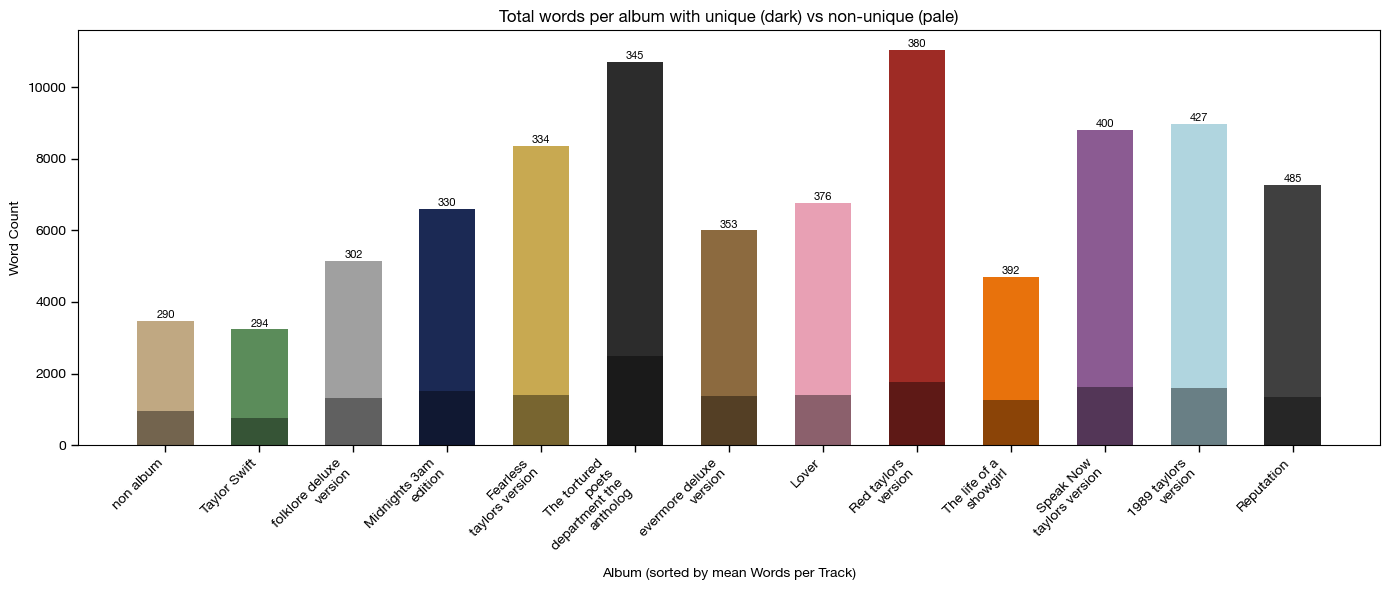

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Helvetica Neue"

pivot_words["Non_Unique_Words"] = pivot_words["Total_Words"] - pivot_words["Unique_Words"]
pivot_words_sorted = pivot_words.sort_values("Words_Per_Track")

def darken_color(hex_color, factor=0.6):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    r, g, b = [int(c * factor) for c in (r, g, b)]
    return f"#{r:02x}{g:02x}{b:02x}"

#Set the colors for each album
album_colors = {
    "Taylor Swift":                          "#5B8C5A",
    pivot_words["Album"].unique()[6]:        "#8B5B92", #Speak now
    pivot_words["Album"].unique()[4]:        "#9E2B25", #Red
    pivot_words["Album"].unique()[5]:        "#404040", #Reputation
    "Lover":                                 "#E8A0B4",
    pivot_words["Album"].unique()[11]:       "#A0A0A0", #Folklore
    pivot_words["Album"].unique()[10]:       "#8C6A3F", #Evermore
    pivot_words["Album"].unique()[1]:        "#C8A951", #Fearless
    pivot_words["Album"].unique()[3]:        "#1B2954", #Midnights
    pivot_words["Album"].unique()[0]:        "#B0D5DF", #1989
    pivot_words["Album"].unique()[9]:         "#2C2C2C", #TTPD
    pivot_words["Album"].unique()[8]:         "#E8720C", #TLOAS
    pivot_words["Album"].unique()[12]:        "#C0A882",  # Non-album (warm parchment)
}

palette       = [album_colors.get(album, "#888888") for album in pivot_words_sorted["Album"]]
palette_dark  = [darken_color(c) for c in palette]


fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(pivot_words_sorted))

ax.bar(x, pivot_words_sorted["Total_Words"], color=palette, width=0.6)
ax.bar(x, pivot_words_sorted["Unique_Words"], color=palette_dark, width=0.6)

for i, row in enumerate(pivot_words_sorted.itertuples()):
    ax.text(i, row.Total_Words + 20, f"{row.Words_Per_Track:.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xlabel("Album (sorted by mean Words per Track)")
ax.set_ylabel("Word Count")
ax.set_title("Total words per album with unique (dark) vs non-unique (pale)")
ax.tick_params(axis='both', which='both', length=5, width=1)

## Split the line for long song name, e.g., All too well (10)
def wrap_label(label, max_width=15):
    words = label.split()
    lines, current = [], ""
    for word in words:
        if len(current) + len(word) + 1 <= max_width:
            current = (current + " " + word).strip()
        else:
            lines.append(current)
            current = word
    lines.append(current)
    return "\n".join(lines)

wrapped_labels = [wrap_label(name) for name in pivot_words_sorted["Album"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/Total_words_per_album.png", dpi=300, bbox_inches='tight') 
plt.show()

The x-axis here is the mean of the total words per track. Reputation has the mean of 485 word counts per track.

#### IA. Word evolution by album

In [211]:
pivot_words_year = pivot_words.sort_values("Year").head(12)

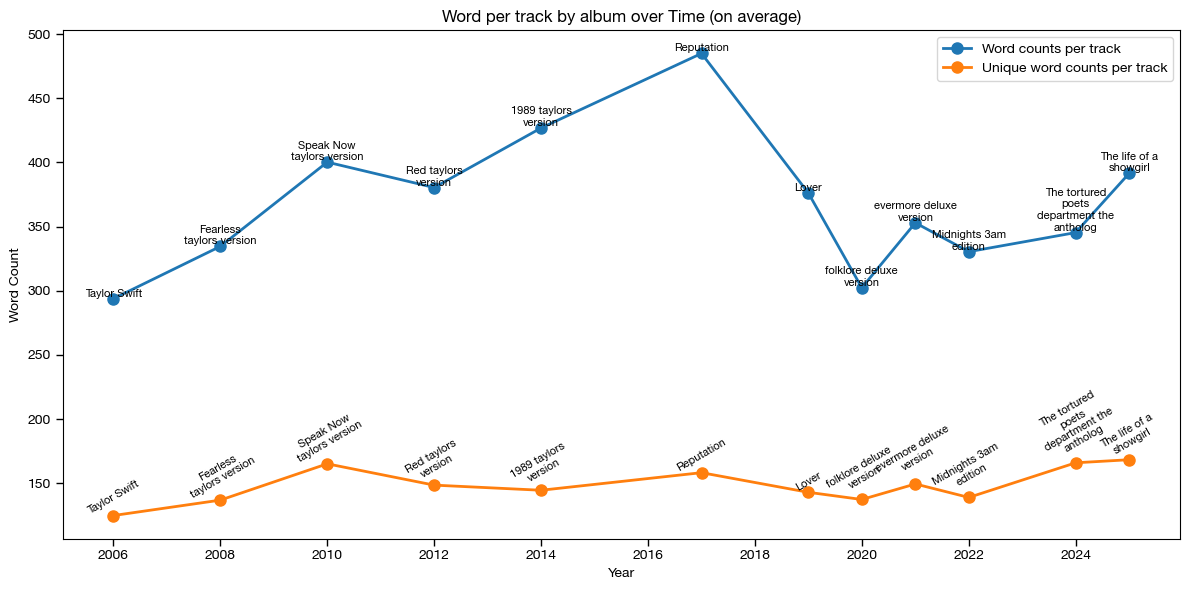

In [306]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pivot_words_year["Year"],pivot_words_year["Words_Per_Track"], 
        marker="o", linewidth=2, markersize=8, label = "Word counts per track")

ax.plot(pivot_words_year["Year"],pivot_words_year["Unique_Words_Per_Track"], 
        marker="o", linewidth=2, markersize=8, label = "Unique word counts per track")

for _, row in pivot_words_year.iterrows():
    ax.text(row["Year"], row["Words_Per_Track"] + 0.002, 
            wrap_label(row["Album"]), ha="center", va="bottom", fontsize=8, rotation=0)
    ax.text(row["Year"], row["Unique_Words_Per_Track"] + 0.002, 
            wrap_label(row["Album"]), ha="center", va="bottom", fontsize=8, rotation=30)

ax.set_xlabel("Year")
ax.set_ylabel("Word Count")
ax.set_title("Word per track by album over Time (on average)")
ax.tick_params(axis='both', which='both', length=5, width=1)
ax.legend()

plt.tight_layout()
plt.savefig("images/Word_per_track_over_time.png", dpi=300, bbox_inches='tight') 
plt.show()

#### What is her unique word ratio over time?

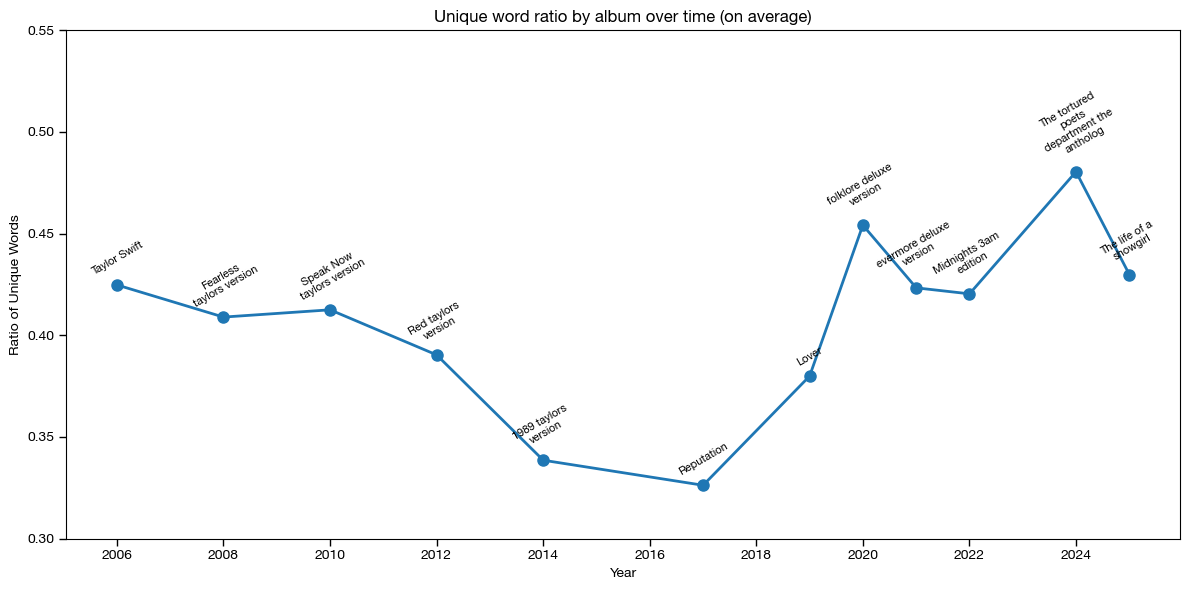

In [214]:
pivot_words_year=pivot_words.sort_values("Year").head(12)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pivot_words_year["Year"],pivot_words_year["Ratio_unique"], 
        marker="o", linewidth=2, markersize=8)

for _, row in pivot_words_year.iterrows():
    ax.text(row["Year"], row["Ratio_unique"] + 0.004, 
            wrap_label(row["Album"]), ha="center", va="bottom", fontsize=8, rotation=30)

ax.set_xlabel("Year")
ax.set_ylabel("Ratio of Unique Words")
ax.set_title("Unique word ratio by album over time (on average)")
ax.tick_params(axis='both', which='both', length=5, width=1)
ax.set_ylim(0.3,0.55)

plt.tight_layout()
plt.savefig("images/Unique_word_per_track_over_time.png", dpi=300, bbox_inches='tight') 
plt.show()

Overall, a growth in terms of amount of words was seen with a regression of unique words from 2006 to 2017. The trend was positive again after folklore era.

#### IB. Signature words by album

This is a cool feature from sklearn that can convert lyrics into numerical vector. We will use the following measure to evaluate the signature words by album.

1. Term frequency (TF): $TF = \frac{\# \text{of word in album}}{\text{total words in album}}$.
2. Inverse Document Frequency (IDF): $IDF= \log\left( \frac{\text{total alumns}}{\text{alumns containing word}} \right)$.

Each word will be assigned in a vector where the numerical value is given by $U = TF \times IDF$. The value $U$ can be thought as a fruency weighted by the "uniqueness" of the word accross different albums. The higher value $U$, the more unique of the word to that album and I define it as a "signature word".

Note that, to see meaningful analysis, I consider word with length $\ge 8$.

In [352]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Drop the non-album
ts_lyrics_album = ts_lyrics[ts_lyrics["Album"] != "non album"]

# Combine all lyrics per album into one document
album_lyrics = ts_lyrics_album.groupby("Album")["Lyrics"].apply(lambda x: ' '.join(x)).reset_index()

# Build TF-IDF matrix at album level
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english',
                             token_pattern=r'\b[a-zA-Z]{8,}\b') #get word with length >= 8
tfidf_matrix = vectorizer.fit_transform(album_lyrics["Lyrics"])
feature_names = vectorizer.get_feature_names_out()

# Get top N signature words per album
def get_top_words(album_idx, n=3):
    scores = tfidf_matrix[album_idx].toarray()[0]
    top_indices = scores.argsort()[::-1][:n]
    return [(feature_names[i], scores[i]) for i in top_indices]

# Build signature words dataframe
signature_words = []
for i, album in enumerate(album_lyrics["Album"]):
    for word, score in get_top_words(i, n=3):
        signature_words.append((album, word, score))

signature_df = pd.DataFrame(signature_words, columns=["Album", "Word", "TF-IDF Score"])
signature_df

,Album,Word,TF-IDF Score
0,1989 taylors version,wonderland,0.757061
1,1989 taylors version,remember,0.219755
2,1989 taylors version,romantics,0.216303
3,Fearless taylors version,fairytale,0.679299
4,Fearless taylors version,hallelujah,0.250268
5,Fearless taylors version,fearless,0.216986
6,Lover,daylight,0.856924
7,Lover,cornelia,0.342770
8,Lover,thousand,0.113767
9,Midnights 3am edition,lavender,0.344011


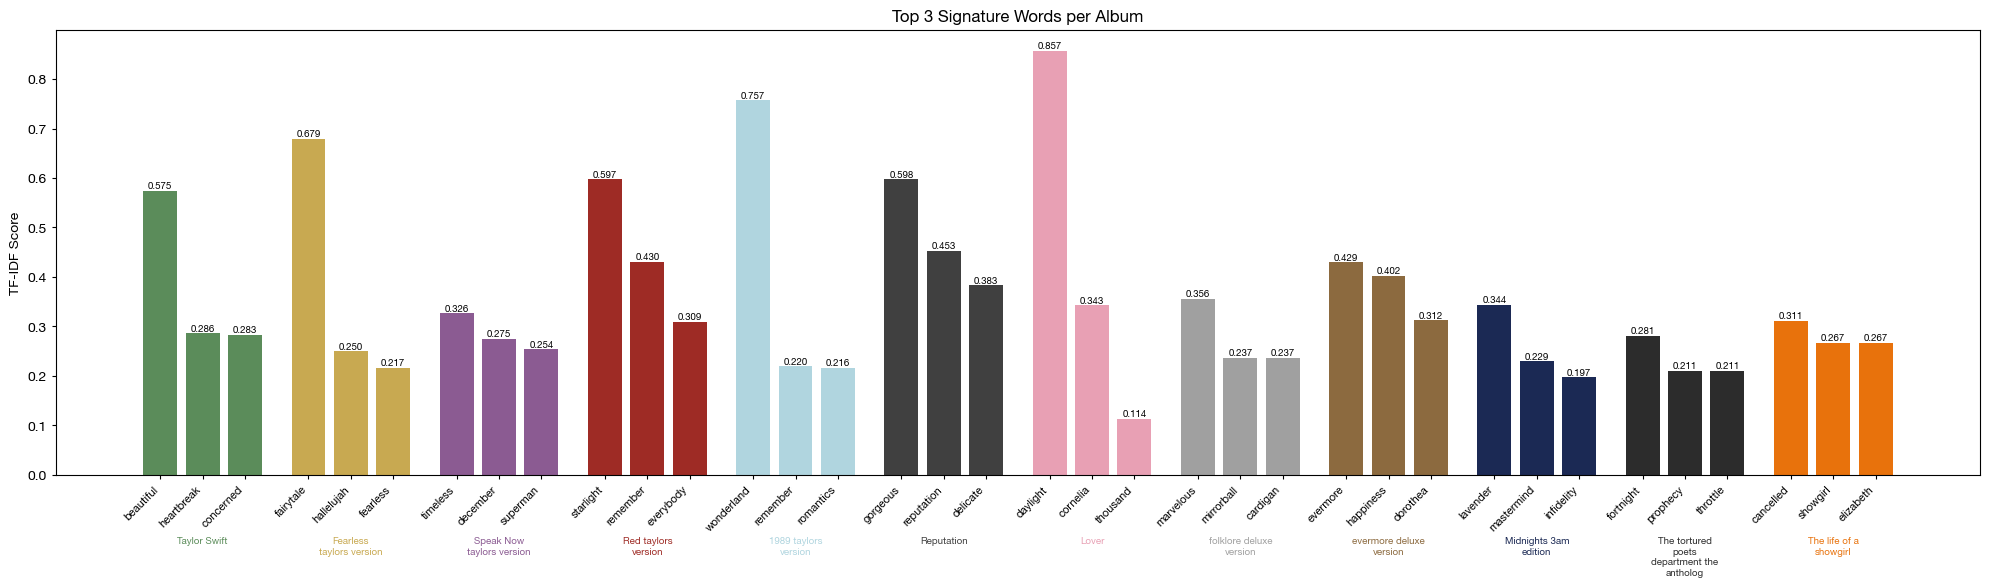

In [376]:
top3 = (signature_df.groupby("Album", group_keys=False)
        .apply(lambda x: x.nlargest(3, "TF-IDF Score"))
        .reset_index(drop=True)
        .merge(album_years, on="Album", how="left")
        .sort_values(["Year", "TF-IDF Score"], ascending=[True, False]))

top3["Label"] = top3["Album"] + "\n" + top3["Word"]

fig, ax = plt.subplots(figsize=(20, 6))

albums_sorted = top3["Album"].unique()
x_positions = []
x_labels = []
x = 0

for album in albums_sorted:
    data = top3[top3["Album"] == album]
    color = album_colors.get(album, "#888888")
    
    for _, row in data.iterrows():
        ax.bar(x, row["TF-IDF Score"], color=color, width=0.8)
        ax.text(x, row["TF-IDF Score"] + 0.0005, f"{row['TF-IDF Score']:.3f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")
        x_labels.append(row["Word"])
        x_positions.append(x)
        x += 1
    
    # Add album label in the middle of its 3 bars
    mid = x - 2
    ax.text(mid, -0.125, wrap_label(album, max_width=15),
            ha="center", va="top", fontsize=7, color=color, fontweight="bold")
    
    x += 0.5  # gap between albums

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("TF-IDF Score")
ax.set_title("Top 3 Signature Words per Album")
ax.tick_params(axis='both', which='both', length=3)

plt.tight_layout()
plt.savefig("images/Signature_words_per_album.png", dpi=300, bbox_inches='tight') 
plt.show()

## II. Analysing words by song <a id="ii-analysing-words-by-song"></a>

### Creating clean word dataframe

In [217]:
#Create a clean word dataframe
import string

word_records = []
for _, row in ts_lyrics.iterrows():
    for word in row["Lyrics"].split():
        clean_word = re.sub(r"['\u2019\u2018`].*", "", word.strip(string.punctuation)) # remove apostrophe and everything after
        
        if "-" in clean_word: #breaking the word with hyphen into individual word
            sub_words = clean_word.split("-")
            for sub_word in sub_words:
                sub_word = sub_word.strip(string.punctuation)
                if sub_word:
                    word_records.append((sub_word, len(sub_word), row["Album"], row["Song Name"]))
        else:
            if clean_word:
                word_records.append((clean_word, len(clean_word), row["Album"], row["Song Name"]))

words_df_clean = pd.DataFrame(word_records, columns=["Word", "Length", "Album", "Song Name"])

In [218]:
words_df_clean.info()

word_total = len(words_df_clean["Word"])
word_unique = len(words_df_clean["Word"].unique())

print("Total songs found are", len(ts_lyrics["Song Name"]))
print("Total words found are", word_total)
print("Unique words found are", word_unique)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91813 entries, 0 to 91812
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Word       91813 non-null  object
 1   Length     91813 non-null  int64 
 2   Album      91813 non-null  object
 3   Song Name  91813 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB
Total songs found are 250
Total words found are 91813
Unique words found are 6013


### IIA. Words by songs

In [220]:
word_by_songs = words_df_clean.groupby("Song Name").agg(
    Word_count=("Word", "count"),
    Word_unique=("Word", "nunique")
).reset_index()
word_by_songs["ratio_unique_total"] = word_by_songs["Word_unique"] / word_by_songs["Word_count"]
word_by_songs.describe()

,Word_count,Word_unique,ratio_unique_total
count,250.000000,250.000000,250.000000
mean,367.252000,136.172000,0.384175
std,99.271465,31.402914,0.083814
min,156.000000,76.000000,0.158192
25%,304.000000,115.000000,0.329827
50%,359.500000,135.000000,0.382981
75%,419.750000,151.750000,0.433050
max,978.000000,349.000000,0.633333


Can you guess what track has the highest word with 978 word counts? A hint is it's a 10-min song.
What stands out to me is that, on average, there is 38% of unique words in a song. I am very curious now which track has the highest unqiue ration with 63%

#### Word distribution

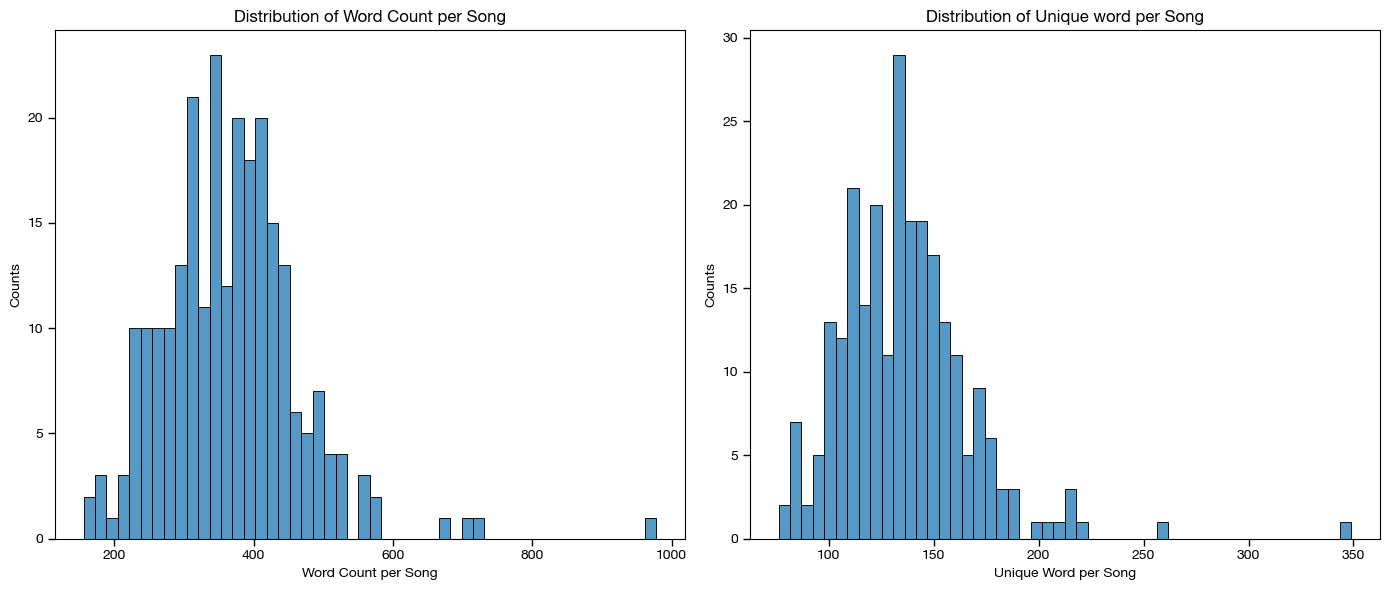

In [223]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=word_by_songs, x="Word_count", bins=50, ax=axes[0])
axes[0].set_xlabel("Word Count per Song")
axes[0].set_ylabel("Counts")
axes[0].set_title("Distribution of Word Count per Song")
axes[0].tick_params(axis='both', which='both', length=5, width=1)

sns.histplot(data=word_by_songs, x="Word_unique", bins=50, ax=axes[1])
axes[1].set_ylabel("Counts")
axes[1].set_xlabel("Unique Word per Song")
axes[1].set_title("Distribution of Unique word per Song")
axes[1].tick_params(axis='both', which='both', length=5, width=1)

plt.tight_layout()
plt.savefig("images/word_histograms.png", dpi=300, bbox_inches='tight') 
plt.show()

#### Top songs by word count

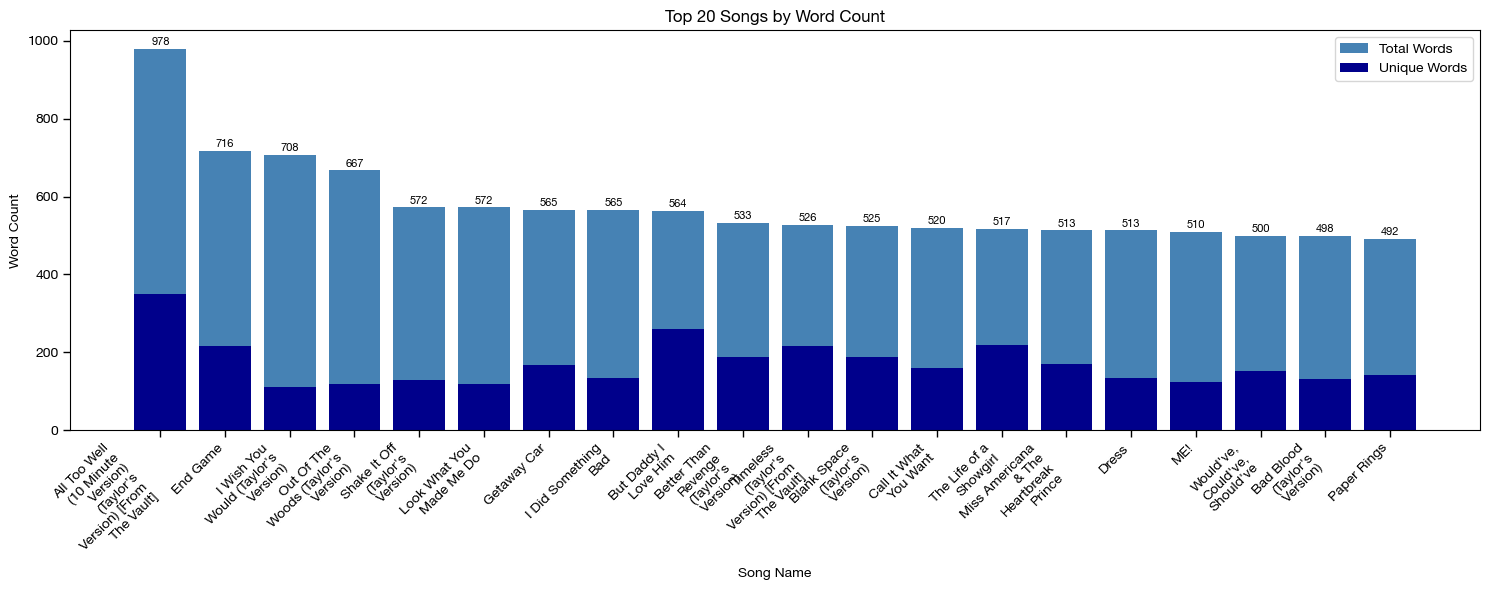

In [225]:
## Get top songs by word counts
top_songs= word_by_songs.sort_values(["Word_count", "Word_unique"], ascending=False).head(20)

## Create a bar chart
fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(range(len(top_songs)), top_songs["Word_count"], 
       color="steelblue", label="Total Words")
ax.bar(range(len(top_songs)), top_songs["Word_unique"], 
       color="darkblue", label="Unique Words")
 
for i, row in enumerate(top_songs.itertuples()):
    ax.text(i, row.Word_count + 5, str(row.Word_count),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_songs)))
ax.set_xlabel("Song Name")
ax.set_ylabel("Word Count")
ax.set_title("Top 20 Songs by Word Count")
ax.legend()
ax.tick_params(axis='both', which='both', length=5, width=1)

wrapped_labels = [wrap_label(name) for name in top_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/top_songs_by_words.png", dpi=300, bbox_inches='tight') 
plt.show()

Clearly, All too well 10-min version should be there.

#### Smallest songs by count

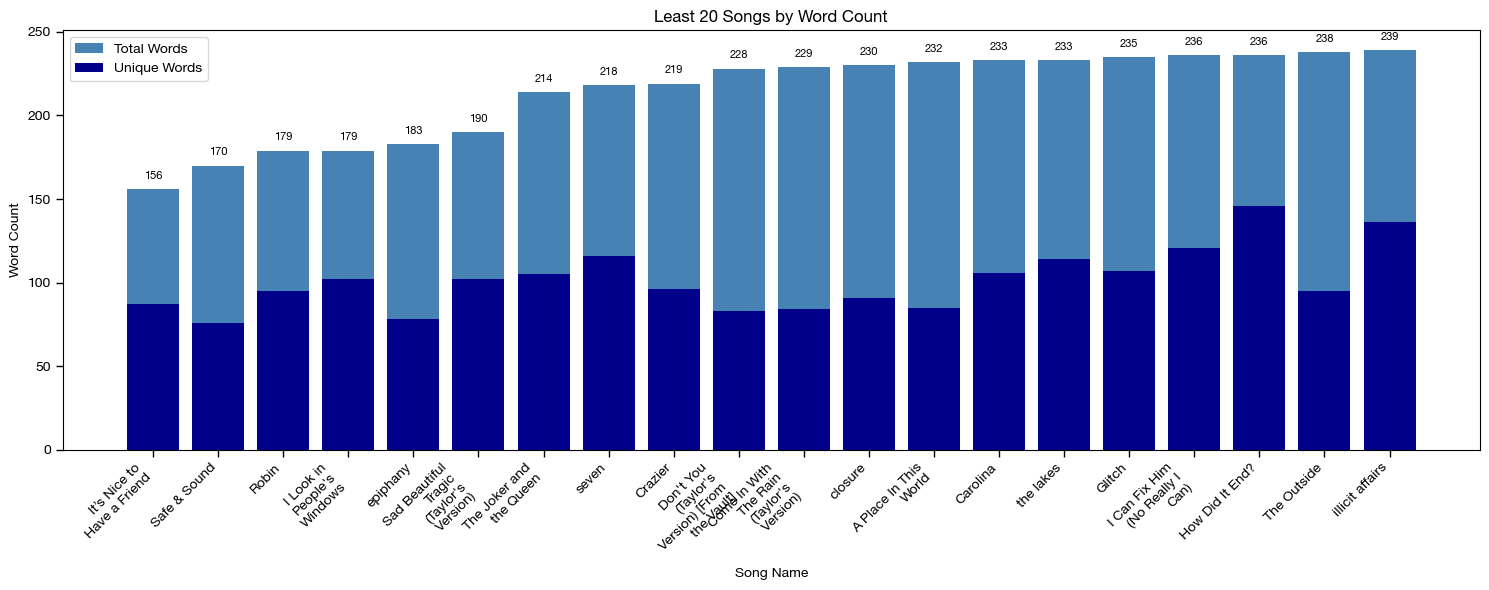

In [304]:
## Get top songs by word counts
top_songs= word_by_songs.sort_values(["Word_count", "Word_unique"], ascending=True).head(20)

## Create a bar chart
fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(range(len(top_songs)), top_songs["Word_count"], 
       color="steelblue", label="Total Words")
ax.bar(range(len(top_songs)), top_songs["Word_unique"], 
       color="darkblue", label="Unique Words")
 
for i, row in enumerate(top_songs.itertuples()):
    ax.text(i, row.Word_count + 5, str(row.Word_count),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_songs)))
ax.set_xlabel("Song Name")
ax.set_ylabel("Word Count")
ax.set_title("Least 20 Songs by Word Count")
ax.legend()
ax.tick_params(axis='both', which='both', length=5, width=1)

wrapped_labels = [wrap_label(name) for name in top_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/smallest_songs_by_words.png", dpi=300, bbox_inches='tight') 
plt.show()

One shouldn't be surprised that it's nice to have a firend is only with a length of 2:30 mins.

#### Top song by unique words

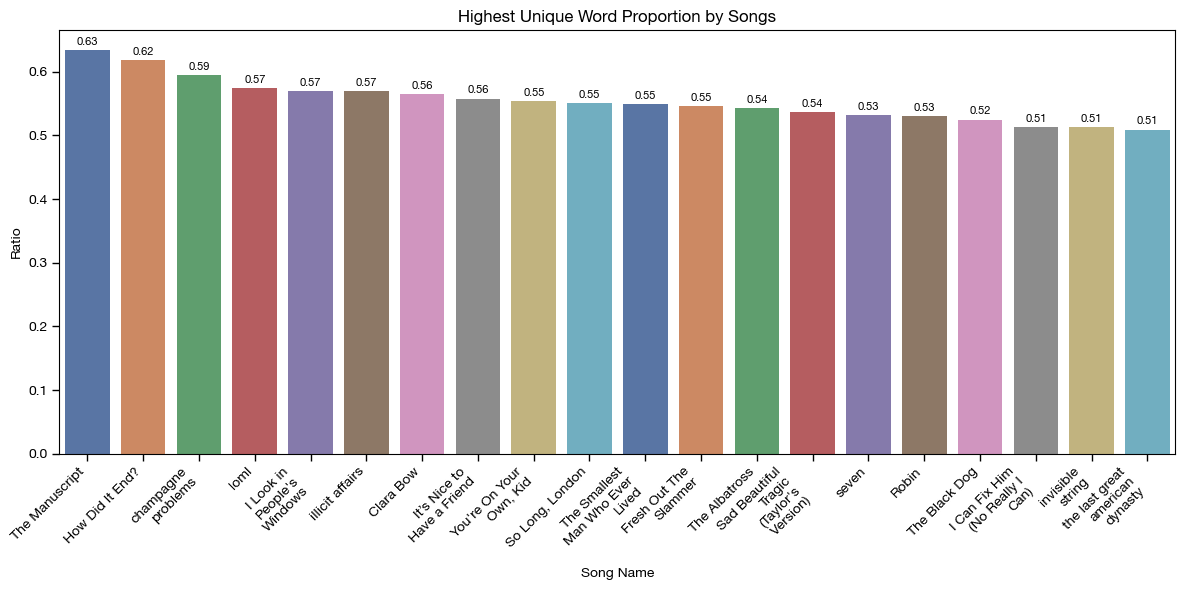

In [231]:
## Get top songs by ratio of unique songs
top_unique_songs = word_by_songs.sort_values("ratio_unique_total", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_unique_songs, x="Song Name", y="ratio_unique_total", 
            hue="Song Name", palette="deep", legend=False, ax=ax)

for i, row in enumerate(top_unique_songs.itertuples()):
    ax.text(i, row.ratio_unique_total + 0.005, f"{row.ratio_unique_total:.2f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_unique_songs)))
ax.set_ylabel("Ratio")
ax.set_title("Highest Unique Word Proportion by Songs")
ax.tick_params(axis='both', which='both', length=5, width=1)
wrapped_labels = [wrap_label(name) for name in top_unique_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/top_unique_songs_by_ratio.png", dpi=300, bbox_inches='tight') 
plt.show()

This is very interesting reults, especially, there are 12 songs from TTPD anthology. Also notice that "It's nice to have a friend" is the smallest song.

#### Least unique propotion songs

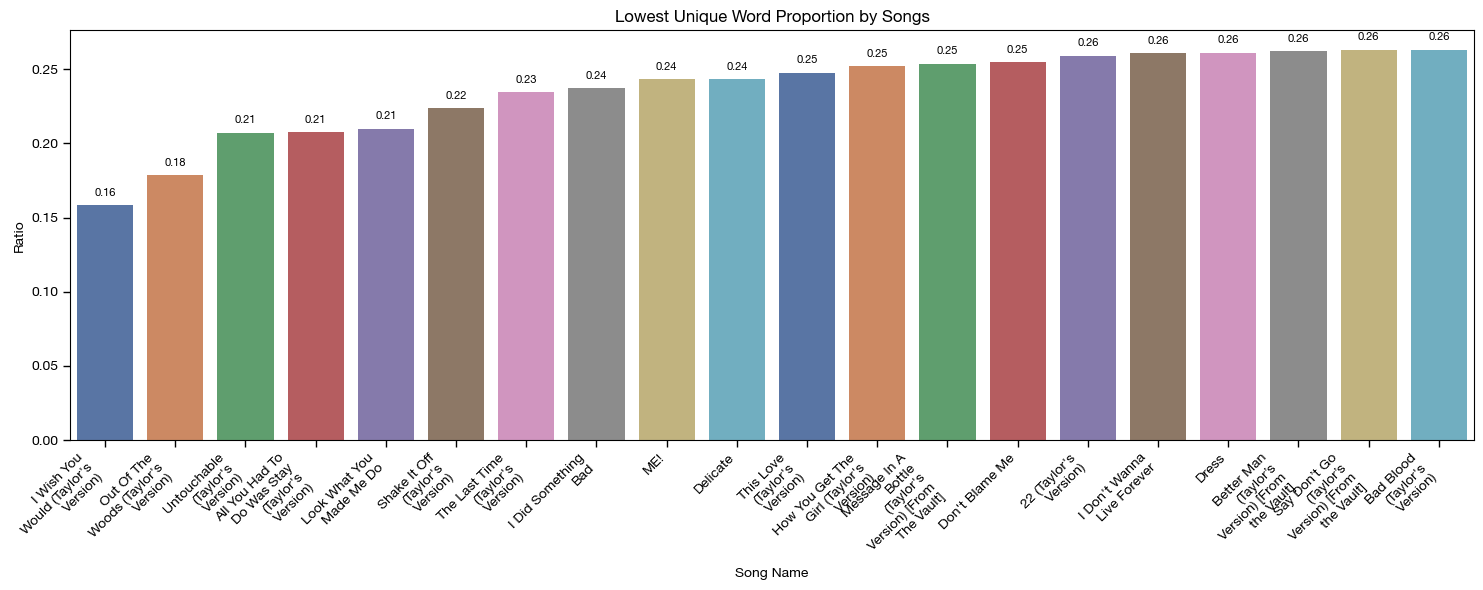

In [234]:
## Get top songs by ratio of unique songs
top_unique_songs = word_by_songs.sort_values("ratio_unique_total", ascending=True).head(20)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=top_unique_songs, x="Song Name", y="ratio_unique_total", 
            hue="Song Name", palette="deep", legend=False, ax=ax)

for i, row in enumerate(top_unique_songs.itertuples()):
    ax.text(i, row.ratio_unique_total + 0.005, f"{row.ratio_unique_total:.2f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_unique_songs)))
ax.set_ylabel("Ratio")
ax.set_title("Lowest Unique Word Proportion by Songs")
ax.tick_params(axis='both', which='both', length=5, width=1)
wrapped_labels = [wrap_label(name) for name in top_unique_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/least_unique_songs_by_ratio.png", dpi=300, bbox_inches='tight') 
plt.show()

I am not surprised at all. I wish you would and out of the woods are the song that repeat these title words multiple times in the songs. There are 8 songs from 1989!

### III. Analysing all words over 251 songs <a id="iii-analysing-all-words-over-251-songs"></a>

#### IIIA. Finding the longes word

In [238]:
#Finding the logest words
words_df_clean.drop_duplicates(subset=["Word", "Song Name"]).sort_values("Length", ascending=False).head(20).set_index("Length")

,Word,Album,Song Name
Length,,,
17,Miscommunications,Speak Now taylors version,The Story Of Us (Taylor's Version)
17,Miscommunications,Midnights 3am edition,Question..
15,Sanctimoniously,The tortured poets department the antholog,But Daddy I Love Him
15,Disappointments,evermore deluxe version,coney island
14,deconstructors,Midnights 3am edition,Sweet Nothing
14,constellations,Midnights 3am edition,High Infidelity
14,responsibility,Red taylors version,Girl At Home (Taylor's Version)
14,insurmountable,folklore deluxe version,the lakes
14,underestimated,Speak Now taylors version,Better Than Revenge (Taylor's Version)


#### IIIB. The most frequently used words with length $\ge 7$

It is more meaning to look for terms with long lenght.Otherwise, we might encounter terms like pronouns, which are the most used in any songs.

Here, let's define a long word as a word that have a length $\ge 7$. 

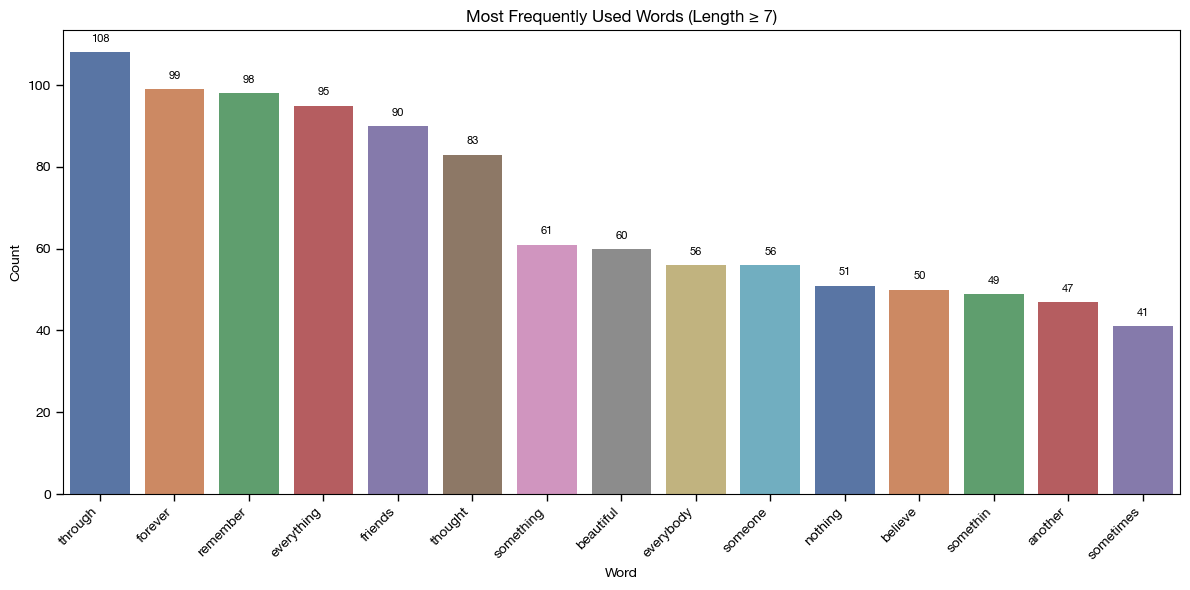

In [241]:
filtered_long = words_df_clean[words_df_clean["Length"] >= 7]
top_words = filtered_long["Word"].str.lower().value_counts().head(15).reset_index()
top_words.columns = ["Word", "Count"]

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=top_words, x="Word", y="Count", hue="Word", palette="deep", legend=False, ax=ax)
for i, row in enumerate(top_words.itertuples()):
    ax.text(i, row.Count + 2, f"{row.Count}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Word")
ax.set_ylabel("Count")
ax.set_title("Most Frequently Used Words (Length ≥ 7)")
ax.tick_params(axis='both', which='both', length=5, width=1)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/most_used_words.png", dpi=300, bbox_inches='tight') 
plt.show()

Obviously, her favourite noun word (that is longer than 6 letters) is "forever". Let's trace back this word which track it appears and how many times.

#### Where to find "forever"?

In [244]:
(words_df_clean[words_df_clean["Word"].str.lower() == "forever"]
 .groupby(["Song Name", "Album"])
 .size()
 .reset_index(name="Count")
 .sort_values("Count", ascending=False)
 .set_index("Count"))

,Song Name,Album
Count,,
10,Elizabeth Taylor,The life of a showgirl
8,Forever & Always (Taylor's Version),Fearless taylors version
8,Forever Winter (Taylor’s Version) [From the Va...,Red taylors version
7,How You Get The Girl (Taylor's Version),1989 taylors version
5,Lover,Lover
5,Enchanted (Taylor's Version),Speak Now taylors version
5,Wonderland (Taylor's Version),1989 taylors version
5,Say Don’t Go (Taylor’s Version) [From the Vault],1989 taylors version
5,Last Kiss (Taylor's Version),Speak Now taylors version


#### IIIC. What is the "long" word that is used the most in a single song?

In [246]:
### Long words that are used the most in a song
(filtered_long
 .groupby([ "Word", "Song Name", "Album"])
 .size()
 .reset_index(name="Count")
 .sort_values("Count", ascending=False)
 .head(25)
 .set_index("Count"))

,Word,Song Name,Album
Count,,,
38,daylight,Daylight,Lover
24,trouble,I Knew You Were Trouble (Taylor's Version),Red taylors version
22,getaway,Getaway Car,Reputation
22,starlight,Starlight (Taylor's Version),Red taylors version
21,Wonderland,Wonderland (Taylor's Version),1989 taylors version
20,everybody,Girl At Home (Taylor's Version),Red taylors version
19,Welcome,Welcome To New York (Taylor's Version),1989 taylors version
18,Florida,Florida!!!,The tortured poets department the antholog
18,remember,All Too Well (10 Minute Version) (Taylor's Ver...,Red taylors version


#### IIID. What are the most used two consecutive words?

In [247]:
from collections import Counter

bigrams = []
for _, row in ts_lyrics.iterrows():
    words = row["Lyrics"].split()
    words = [re.sub(r"['\u2019\u2018`].*", "", w.strip(string.punctuation)).lower() for w in words]
    words = [w for w in words if w]
    for i in range(len(words) - 1):
        bigrams.append((words[i], words[i+1]))

bigram_counts = Counter(bigrams)
bigram_df = pd.DataFrame(bigram_counts.most_common(10), columns=["Bigram", "Count"])
bigram_df

,Bigram,Count
0,"(and, i)",520
1,"(in, the)",416
2,"(but, i)",253
3,"(i, was)",239
4,"(i, can)",236
5,"(i, don)",204
6,"(and, you)",195
7,"(on, the)",194
8,"(i, know)",181
9,"(you, were)",170


#### IIIE. Which songs are the most similar?

This is a cool feature from sklearn that can convert lyrics into numerical vector. Then use cosine similary to evaluate the closeness of each song.


(For tecnhical people)

The math behind it is very simple. 

For vectorisation of the lyrics: using Term freuqency and Inverse Document Frequency. Read [here](https://en.wikipedia.org/wiki/Tf%E2%80%93idf).

For similarity: Basically, a dot product of two vector can be written as $\cos(\theta) = \frac{A\dot B}{|A||B|}$. So the output of 'cosine_sim' can range from 0 to 1.

In [330]:
from sklearn.metrics.pairwise import cosine_similarity

# Build TF-IDF matrix
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(ts_lyrics["Lyrics"])

# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix)

# Convert to dataframe
cosine_df = pd.DataFrame(cosine_sim, 
                         index=ts_lyrics["Song Name"], 
                         columns=ts_lyrics["Song Name"])

# Find most similar pairs (excluding self-similarity)
pairs = []
songs = ts_lyrics["Song Name"].values
for i in range(len(songs)):
    for j in range(i+1, len(songs)):
        pairs.append((songs[i], songs[j], cosine_sim[i, j]))

pairs_df = (pd.DataFrame(pairs, columns=["Song 1", "Song 2", "Similarity"])
            .sort_values("Similarity", ascending=False)
            .reset_index(drop=True))

pairs_df.head(20)

,Song 1,Song 2,Similarity
0,All Too Well (10 Minute Version) (Taylor's Ver...,All Too Well (Taylor's Version),0.847386
1,dorothea,Safe & Sound,0.558664
2,I Bet You Think About Me (Taylor's Version) [F...,I Almost Do (Taylor's Version),0.556517
3,You Need To Calm Down,Opalite,0.507643
4,You Need To Calm Down,My Boy Only Breaks His Favorite Toys,0.507089
5,Fifteen (Taylor's Version),Superman (Taylor's Version),0.499942
6,Wildest Dreams (Taylor's Version),Dress,0.481616
7,Stay Stay Stay (Taylor's Version),All You Had To Do Was Stay (Taylor's Version),0.480540
8,ME!,Safe & Sound,0.479411
9,Fifteen (Taylor's Version),Foolish One (Taylor's Version) [From The Vault],0.478032


#### Least similar songs

In [296]:
pairs_df.tail(12)

,Song 1,Song 2,Similarity
31113,Holy Ground (Taylor's Version),The Joker and the Queen,0.000075
31114,Glitch,The Joker and the Queen,0.000000
31115,Forever Winter (Taylor’s Version) [From the Va...,The Joker and the Queen,0.000000
31116,The Joker and the Queen,Eyes Open,0.000000
31117,You Are In Love (Taylor's Version),The Joker and the Queen,0.000000
31118,Change (Taylor's Version),The Joker and the Queen,0.000000
31119,Question..,The Joker and the Queen,0.000000
31120,Tied Together with a Smile,The Joker and the Queen,0.000000
31121,Babe (Taylor’s Version) [From the Vault],The Joker and the Queen,0.000000
31122,epiphany,The Joker and the Queen,0.000000


In [302]:
# Find most similar songs to a specific track
song = "Safe & Sound"
cosine_df[song].sort_values(ascending=False)[1:10]  # top 5, excluding itself

Song Name
dorothea                                              0.558664
ME!                                                   0.479411
invisible string                                      0.408913
Holy Ground (Taylor's Version)                        0.370180
It’s Nice to Have a Friend                            0.356625
Soon You'll Get Better                                0.350486
Forever Winter (Taylor’s Version) [From the Vault]    0.299863
Afterglow                                             0.265814
All Of The Girls You Loved Before                     0.258286
Name: Safe & Sound, dtype: float64

## IV. Conclusion and Discussion <a id="iv-conclusion-and-discussion"></a>

In this notebook, I have conducted an analysis of Taylor Swift's lyrics over 251 songs. Starting from analysing lyrics by album, I found that **Reputation has the highest mean word count per track**, while **The Life of a Showgirl has the highest mean unique word count per track**. Regarding the unique words in an entire album, **The Tortured Poets Department: The Anthology has the highest unique word ratio at 48%**. Overall, a growth in the amount of words was observed, with a regression of unique words from 2006 to 2017. The trend was positive again after the Folklore era. Word signatures are also identified. Overwhelmingly, **"Daylight" was an *obvious* signature of the Lover era**, as well as **"Wonderland" in the 1989 era**.

Moving to words by song, the largest amount of words is from "All Too Well (10-Minute Version)", which is, of course, a 10-minute song, while "It's Nice to Have a Friend" has the smallest count (it is a 2:30 min song). However, the most interesting result from this analysis is that **"The Manuscript" is the most unique song, containing 68% unique words**. In fact, among the top 10 unique word songs, **12 songs** are from The Tortured Poets Department, which is quite impressive. "I Wish You Would" is the song with the most repetitive words, with the lowest unique ratio in her discography.

Looking at the entire lyrics across 251 songs, I found the longest words that appear in her music. With a length of 17 letters, it is **"Miscommunications"**, appearing in two songs: "Story of Us" from Speak Now and "Question...?" from Midnights. **"Sanctimoniously"** is the second longest, from "But Daddy I Love Him". **"Forever"** is the most used noun word with length $\ge 7$ in her entire lyrics, appearing 10 times in "Elizabeth Taylor" from The Life of a Showgirl.

I also found that among words with length $\ge 7$, **"Daylight"** is the most repetitive word in a single song, appearing 38 times in "Daylight" from Lover, followed by **"Trouble"**, which appears 24 times in "I Knew You Were Trouble" from Red. **"And I"** are the most frequent two consecutive words in her entire lyrics, followed by **"In the"**. Lyrically, **All Too Well (10-Minute Version)** and **All Too Well** are the most similar songs, as one is an extension of the other. However, **Dorothea** and **Safe & Sound** are the second most similar pair, with 55% similarity.

### Discussion
There are some limitations of this analysis, which may motivate further work. First, some words are treated as different entities — for example, "remember" and "remembered" are counted as two separate words. Second, there are songs commonly associated with Taylor Swift that she did not perform, such as "This Is What You Came For", which are not included in this analysis. Last, some lyrics may not be included as the data are retrived from "Taylor's version" to include all musics all the vault. For example, I missed the original lyrics of the song "Better than revenge". The phrase *does on the matress* was not analysed.